# EDA - The Movies Dataset

Descarga del dataset [`rounakbanik/the-movies-dataset`](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset) via `kagglehub` y unificacion de sus CSVs (`movies_metadata.csv`, `credits.csv`, `keywords.csv`) en un unico objeto por pelicula.

Las columnas que en el CSV original vienen como JSON stringificado (generos, reparto, equipo tecnico, keywords, compañias/paises productores, idiomas) se parsean y se dejan como listas de valores (por ejemplo nombres), descartando los ids internos de esas entidades. El unico id que se conserva es el `id` de la pelicula, usado como referencia.

> Nota: `kagglehub` requiere credenciales de Kaggle configuradas (`~/.kaggle/kaggle.json` o las variables de entorno `KAGGLE_USERNAME` / `KAGGLE_KEY`).

In [1]:
import ast
import json
import os

import kagglehub
import numpy as np
import pandas as pd

## 1. Descarga del dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: C:\Users\garza\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7


['credits.csv',
 'keywords.csv',
 'links.csv',
 'links_small.csv',
 'movies_metadata.csv',
 'ratings.csv',
 'ratings_small.csv']

## 2. Carga de los CSVs

Usamos `movies_metadata.csv`, `credits.csv` y `keywords.csv`. `low_memory=False` evita warnings por columnas con tipos mixtos (dataset conocido por tener algunas filas corruptas).

In [3]:
movies_metadata = pd.read_csv(os.path.join(path, "movies_metadata.csv"), low_memory=False)
credits = pd.read_csv(os.path.join(path, "credits.csv"))
keywords = pd.read_csv(os.path.join(path, "keywords.csv"))

movies_metadata.shape, credits.shape, keywords.shape

((45466, 24), (45476, 3), (46419, 2))

## 3. Limpieza de ids

`movies_metadata.csv` tiene algunas filas corruptas (columnas desalineadas) donde `id` no es numerico. Las descartamos.

In [4]:
movies_metadata["id"] = pd.to_numeric(movies_metadata["id"], errors="coerce")
movies_metadata = movies_metadata.dropna(subset=["id"]).copy()
movies_metadata["id"] = movies_metadata["id"].astype(int)

# nos quedamos con la primera aparicion de cada id
movies_metadata = movies_metadata.drop_duplicates(subset="id", keep="first")
credits = credits.drop_duplicates(subset="id", keep="first")
keywords = keywords.drop_duplicates(subset="id", keep="first")

movies_metadata.shape, credits.shape, keywords.shape

((45433, 24), (45432, 3), (45432, 2))

## 4. Parseo de columnas JSON stringificado

Columnas como `genres`, `production_companies`, `cast`, `crew`, `keywords` vienen como texto con formato tipo Python (comillas simples), no JSON valido. Se parsean con `ast.literal_eval` y se extraen solo los valores relevantes (ej. `name`), descartando los ids internos de cada entidad.

In [5]:
def safe_literal_eval(value):
    if pd.isna(value):
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []


def extract_names(value, key="name"):
    items = safe_literal_eval(value)
    if not isinstance(items, list):
        return []
    return [item[key] for item in items if isinstance(item, dict) and key in item]


def extract_directors(crew_value):
    crew = safe_literal_eval(crew_value)
    if not isinstance(crew, list):
        return []
    return [member["name"] for member in crew if isinstance(member, dict) and member.get("job") == "Director"]


def extract_collection_name(value):
    if pd.isna(value):
        return None
    collection = safe_literal_eval(value)
    if isinstance(collection, dict):
        return collection.get("name")
    return None

In [6]:
movies_metadata["genres"] = movies_metadata["genres"].apply(extract_names)
movies_metadata["production_companies"] = movies_metadata["production_companies"].apply(extract_names)
movies_metadata["production_countries"] = movies_metadata["production_countries"].apply(extract_names)
movies_metadata["spoken_languages"] = movies_metadata["spoken_languages"].apply(extract_names)
movies_metadata["collection"] = movies_metadata["belongs_to_collection"].apply(extract_collection_name)

In [7]:
credits["cast"] = credits["cast"].apply(extract_names)
credits["directors"] = credits["crew"].apply(extract_directors)

In [8]:
keywords["keywords"] = keywords["keywords"].apply(extract_names)

## 5. Unificacion en un objeto por pelicula

Se combinan los tres datasets por `id` y se seleccionan los campos finales. Cada pelicula queda como un objeto con sus datos internos (generos, reparto, directores, keywords, etc.) como listas de valores, sin ids internos salvo el `id` de la pelicula.

In [9]:
metadata_cols = [
    "id", "title", "original_title", "overview", "tagline", "status",
    "release_date", "runtime", "budget", "revenue", "popularity",
    "vote_average", "vote_count", "original_language", "collection",
    "genres", "production_companies", "production_countries", "spoken_languages",
]

unified = (
    movies_metadata[metadata_cols]
    .merge(credits[["id", "cast", "directors"]], on="id", how="left")
    .merge(keywords[["id", "keywords"]], on="id", how="left")
)

for list_col in ["cast", "directors", "keywords"]:
    unified[list_col] = unified[list_col].apply(lambda v: v if isinstance(v, list) else [])

# pandas usa NaN/NaT para valores faltantes, que no son JSON valido (Python los
# serializa como el token literal `NaN`); los convertimos a None -> JSON null
unified = unified.astype(object).where(unified.notna(), None)

unified.shape

(45433, 22)

In [10]:
def clean_line_separators(value):
    # algunos textos (overview/tagline) traen caracteres Unicode Line/Paragraph
    # Separator, validos en JSON pero marcados por editores como VS Code como
    # "unusual line terminators"
    if isinstance(value, str):
        return value.replace(chr(0x2028), " ").replace(chr(0x2029), " ")
    if isinstance(value, list):
        return [clean_line_separators(v) for v in value]
    if isinstance(value, dict):
        return {k: clean_line_separators(v) for k, v in value.items()}
    return value


records = unified.to_dict(orient="records")
records = [clean_line_separators(r) for r in records]

print(json.dumps(records[0], indent=2, ensure_ascii=False, default=str))

{
  "id": 862,
  "title": "Toy Story",
  "original_title": "Toy Story",
  "overview": "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",
  "tagline": null,
  "status": "Released",
  "release_date": "1995-10-30",
  "runtime": 81.0,
  "budget": "30000000",
  "revenue": 373554033.0,
  "popularity": "21.946943",
  "vote_average": 7.7,
  "vote_count": 5415.0,
  "original_language": "en",
  "collection": "Toy Story Collection",
  "genres": [
    "Animation",
    "Comedy",
    "Family"
  ],
  "production_companies": [
    "Pixar Animation Studios"
  ],
  "production_countries": [
    "United States of America"
  ],
  "spoken_languages": [
    "English"
  ],
  "cast": [
    "Tom Hanks",
    "Tim Allen",
    "Don Rickles",
    "Jim Varney",
  

## 6. Guardar el dataset unificado

In [11]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "movies_unified.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2, default=str, allow_nan=False)

print(f"Guardadas {len(records)} peliculas en {output_path}")

Guardadas 45433 peliculas en data\movies_unified.json


In [12]:
sample_path = os.path.join(output_dir, "movies_unified_sample.json")

with open(sample_path, "w", encoding="utf-8") as f:
    json.dump(records[:10], f, ensure_ascii=False, indent=2, default=str, allow_nan=False)

print(f"Guardada muestra de 10 peliculas en {sample_path}")

Guardada muestra de 10 peliculas en data\movies_unified_sample.json


## 7. Muestra representativa: directores mas proliferos por genero

Se arma un subconjunto de `TAMANIO_MUESTRA` peliculas pensado para ser representativo
del dataset completo:

1. Se usa el primer genero de cada pelicula como "genero principal" (evita contar la
   misma pelicula en mas de un genero al calcular proporciones).
2. Se calcula la proporcion de cada genero en el dataset completo y se la traslada al
   tamaño de la muestra (muestreo estratificado), para que la distribucion de generos
   de la muestra se parezca a la original.
3. Dentro de cada genero, se identifican los `N_DIRECTORES_TOP` directores con mas
   peliculas en ese genero (los "mas proliferos") y se arma la muestra priorizando
   peliculas de esos directores.
4. Si las peliculas de esos directores no alcanzan para cubrir el cupo del genero, se
   completa con el resto de peliculas de ese genero, elegidas al azar.
5. Si aun asi falta para llegar a `TAMANIO_MUESTRA` (por redondeos), se completa al azar
   con el resto del dataset.

In [13]:
from collections import Counter

N_DIRECTORES_TOP = 5      # directores mas proliferos a considerar por genero
TAMANIO_MUESTRA = 1000    # cantidad total de peliculas en la muestra
SEMILLA_ALEATORIA = 42    # reproducibilidad de los sampleos al azar

# solo peliculas con al menos un genero informado
muestreo = unified[unified["genres"].apply(lambda g: len(g) > 0)].copy()
muestreo["genero_principal"] = muestreo["genres"].apply(lambda g: g[0])

# proporcion de cada genero en el dataset completo
conteo_generos = muestreo["genero_principal"].value_counts()
proporcion_generos = conteo_generos / conteo_generos.sum()

# cupo de peliculas por genero para que la muestra sea representativa
cupos_por_genero = (proporcion_generos * TAMANIO_MUESTRA).round().astype(int)

# el redondeo puede dejar la suma en 999 o 1001: se ajusta en el genero mas grande
diferencia = TAMANIO_MUESTRA - cupos_por_genero.sum()
if diferencia != 0:
    genero_mas_grande = cupos_por_genero.idxmax()
    cupos_por_genero[genero_mas_grande] += diferencia

cupos_por_genero.sort_values(ascending=False)

genero_principal
Drama              280
Comedy             205
Action             104
Documentary         79
Horror              61
Crime               39
Thriller            39
Adventure           35
Romance             28
Animation           26
Fantasy             16
Science Fiction     15
Mystery             13
Family              12
Music               11
Western             10
TV Movie             9
War                  9
History              6
Foreign              3
Name: count, dtype: int64

In [14]:
seleccionadas_ids: list[int] = []

for genero, cupo in cupos_por_genero.items():
    peliculas_genero = muestreo[muestreo["genero_principal"] == genero]

    # directores mas proliferos dentro de este genero (una pelicula puede tener varios directores)
    conteo_directores = Counter(
        director
        for lista_directores in peliculas_genero["directors"]
        for director in lista_directores
    )
    top_directores = {director for director, _ in conteo_directores.most_common(N_DIRECTORES_TOP)}

    candidatas = peliculas_genero[
        peliculas_genero["directors"].apply(lambda lista: any(d in top_directores for d in lista))
    ]

    if len(candidatas) >= cupo:
        elegidas = candidatas.sample(n=cupo, random_state=SEMILLA_ALEATORIA)
    else:
        faltantes = cupo - len(candidatas)
        resto_genero = peliculas_genero.drop(candidatas.index)
        relleno = resto_genero.sample(n=min(faltantes, len(resto_genero)), random_state=SEMILLA_ALEATORIA)
        elegidas = pd.concat([candidatas, relleno])

    seleccionadas_ids.extend(elegidas["id"].tolist())

# el redondeo por genero puede dejar la muestra corta: se completa al azar con el resto del dataset
seleccionadas_ids = list(dict.fromkeys(seleccionadas_ids))
if len(seleccionadas_ids) < TAMANIO_MUESTRA:
    faltan = TAMANIO_MUESTRA - len(seleccionadas_ids)
    resto_general = muestreo[~muestreo["id"].isin(seleccionadas_ids)]
    relleno_general = resto_general.sample(n=min(faltan, len(resto_general)), random_state=SEMILLA_ALEATORIA)
    seleccionadas_ids.extend(relleno_general["id"].tolist())

muestra_representativa = unified[unified["id"].isin(seleccionadas_ids)].copy()
muestra_representativa.shape

(1000, 22)

In [15]:
# verificacion: comparar la proporcion de cada genero en la muestra vs. el dataset original
proporcion_muestra = (
    muestra_representativa["genres"]
    .apply(lambda g: g[0] if len(g) > 0 else None)
    .value_counts(normalize=True)
)

comparacion_generos = pd.DataFrame({
    "proporcion_original": proporcion_generos,
    "proporcion_muestra": proporcion_muestra,
}).fillna(0)

comparacion_generos["diferencia_pp"] = (
    (comparacion_generos["proporcion_muestra"] - comparacion_generos["proporcion_original"]) * 100
)

comparacion_generos.sort_values("proporcion_original", ascending=False)

,proporcion_original,proporcion_muestra,diferencia_pp
Drama,0.278035,0.280,0.196506
Comedy,0.205066,0.205,-0.006618
Action,0.104371,0.104,-0.037068
Documentary,0.079389,0.079,-0.038871
Horror,0.060920,0.061,0.008027
Crime,0.039171,0.039,-0.017099
Thriller,0.038683,0.039,0.031749
Adventure,0.035100,0.035,-0.010037
Romance,0.027703,0.028,0.029653
Animation,0.026145,0.026,-0.014501


### Guardar la muestra representativa

In [16]:
registros_muestra_representativa = muestra_representativa.to_dict(orient="records")
registros_muestra_representativa = [clean_line_separators(r) for r in registros_muestra_representativa]

muestra_representativa_path = os.path.join(output_dir, "datos.json")

with open(muestra_representativa_path, "w", encoding="utf-8") as f:
    json.dump(registros_muestra_representativa, f, ensure_ascii=False, indent=2, default=str, allow_nan=False)

print(f"Guardadas {len(registros_muestra_representativa)} peliculas en {muestra_representativa_path}")

Guardadas 1000 peliculas en data\datos.json


## 8. EDA del dataset unificado

Analisis exploratorio de `data/movies_unified.json` (el JSON generado en la seccion 6). Esta seccion es independiente de las anteriores: no descarga nada ni reescribe archivos, solo lee el JSON, asi que se puede correr sola sin volver a ejecutar todo el notebook.

1. Conversion del JSON a un `DataFrame` de pandas y limpieza de tipos.
2. Composicion de la muestra: completitud de los campos y graficos unidimensionales (histogramas, diagramas de caja y bigotes y distribuciones categoricas).
3. Correlaciones: matriz de correlacion y graficos tridimensionales.

In [17]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

# Paleta: un solo color para series unicas, rampa de un solo tono para magnitudes
# y un par azul/rojo con punto medio gris para correlaciones (positivo/negativo).
COLOR_SERIE = "#2a78d6"
COLOR_SECUNDARIO = "#eb6834"
TEXTO_PRIMARIO = "#0b0b0b"
TEXTO_SECUNDARIO = "#52514e"
GRILLA = "#e4e3df"
SUPERFICIE = "#fcfcfb"

CMAP_SECUENCIAL = LinearSegmentedColormap.from_list(
    "azul_secuencial", ["#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list(
    "rojo_gris_azul", ["#9e2a2a", "#e34948", "#f0efec", "#3987e5", "#104281"]
)

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor": SUPERFICIE,
    "axes.edgecolor": GRILLA,
    "axes.labelcolor": TEXTO_SECUNDARIO,
    "axes.titlecolor": TEXTO_PRIMARIO,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRILLA,
    "grid.linewidth": 0.6,
    "xtick.color": TEXTO_SECUNDARIO,
    "ytick.color": TEXTO_SECUNDARIO,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 100,
})


def formato_compacto(valor: float) -> str:
    """1234 -> '1.234', 8000000 -> '8 M', 16834227 -> '16,8 M'."""
    if abs(valor) >= 1e9:
        return f"{valor / 1e9:.3g} MM".replace(".", ",")
    if abs(valor) >= 1e6:
        return f"{valor / 1e6:.3g} M".replace(".", ",")
    if float(valor).is_integer():
        return f"{int(valor):,}".replace(",", ".")
    return f"{valor:.3g}".replace(".", ",")


# para ejes donde se grafica log10(valor): el tick 6 se muestra como 10^6
FORMATO_POTENCIA_10 = FuncFormatter(lambda valor, _: f"$10^{{{valor:g}}}$")

### 8.1 Del JSON a un DataFrame

Cada pelicula del JSON es un objeto, asi que `pd.DataFrame` lo convierte directamente en una fila. Despues se ajustan los tipos:

- `budget` y `popularity` vienen como texto: se pasan a numero.
- `release_date` se pasa a fecha y se extrae el `anio`.
- En `budget`, `revenue` y `runtime` un **0 significa "sin dato"**, no un valor real (no hay peliculas de 0 minutos ni con presupuesto 0). Se reemplazan por `NaN` para que no deformen las distribuciones.
- `vote_average` vale 0 cuando la pelicula no tiene votos (`vote_count == 0`): tambien es `NaN`.
- Para las columnas que son listas (generos, reparto, etc.) se agrega una columna `n_<campo>` con la cantidad de elementos.

In [18]:
RUTA_JSON_UNIFICADO = Path("data") / "movies_unified.json"

with open(RUTA_JSON_UNIFICADO, encoding="utf-8") as archivo:
    peliculas = pd.DataFrame(json.load(archivo))

for columna in ["budget", "popularity", "revenue", "runtime", "vote_average", "vote_count"]:
    peliculas[columna] = pd.to_numeric(peliculas[columna], errors="coerce")

for columna in ["budget", "revenue", "runtime"]:
    peliculas[columna] = peliculas[columna].replace(0, np.nan)
peliculas.loc[peliculas["vote_count"].fillna(0) == 0, "vote_average"] = np.nan

peliculas["release_date"] = pd.to_datetime(peliculas["release_date"], errors="coerce")
peliculas["anio"] = peliculas["release_date"].dt.year

COLUMNAS_LISTA = [
    "genres", "production_companies", "production_countries",
    "spoken_languages", "cast", "directors", "keywords",
]
for columna in COLUMNAS_LISTA:
    peliculas[f"n_{columna}"] = peliculas[columna].apply(lambda v: len(v) if isinstance(v, list) else 0)

print(f"{len(peliculas):,} peliculas x {peliculas.shape[1]} columnas")
peliculas.head(3)

45,433 peliculas x 30 columnas


,id,title,original_title,overview,tagline,status,release_date,runtime,budget,revenue,...,directors,keywords,anio,n_genres,n_production_companies,n_production_countries,n_spoken_languages,n_cast,n_directors,n_keywords
0,862,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...",NaN,Released,1995-10-30,81.0,30000000.0,373554033.0,...,[John Lasseter],"[jealousy, toy, boy, friendship, friends, riva...",1995.0,3,1,1,1,13,1,9
1,8844,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,Released,1995-12-15,104.0,65000000.0,262797249.0,...,[Joe Johnston],"[board game, disappearance, based on children'...",1995.0,3,3,1,2,26,1,6
2,15602,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,Released,1995-12-22,101.0,NaN,NaN,...,[Howard Deutch],"[fishing, best friend, duringcreditsstinger, o...",1995.0,2,2,1,1,7,1,4


In [19]:
peliculas.info()

<class 'pandas.DataFrame'>
RangeIndex: 45433 entries, 0 to 45432
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      45433 non-null  int64         
 1   title                   45430 non-null  str           
 2   original_title          45433 non-null  str           
 3   overview                44479 non-null  str           
 4   tagline                 20401 non-null  str           
 5   status                  45349 non-null  str           
 6   release_date            45346 non-null  datetime64[us]
 7   runtime                 43615 non-null  float64       
 8   budget                  8880 non-null   float64       
 9   revenue                 7398 non-null   float64       
 10  popularity              45430 non-null  float64       
 11  vote_average            42534 non-null  float64       
 12  vote_count              45430 non-null  float64       
 1

### 8.2 Completitud de los campos

Porcentaje de peliculas que tienen cada campo informado. Una lista vacia (por ejemplo sin generos) cuenta como faltante, igual que un `NaN`.

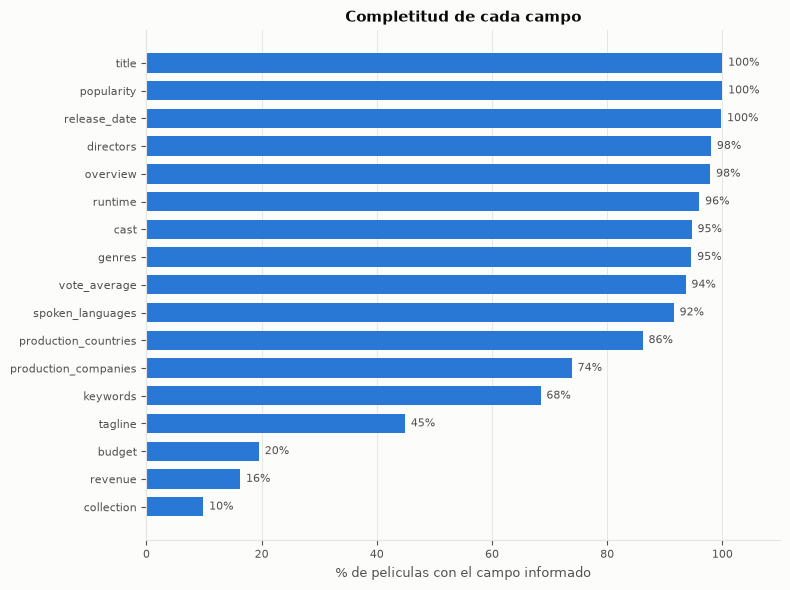

In [20]:
def porcentaje_informado(serie: pd.Series) -> float:
    if serie.apply(lambda v: isinstance(v, list)).any():
        return serie.apply(lambda v: isinstance(v, list) and len(v) > 0).mean() * 100
    return serie.notna().mean() * 100


columnas_completitud = [
    "title", "overview", "tagline", "release_date", "runtime", "budget", "revenue",
    "popularity", "vote_average", "collection", *COLUMNAS_LISTA,
]
completitud = pd.Series(
    {columna: porcentaje_informado(peliculas[columna]) for columna in columnas_completitud}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(completitud.index, completitud.values, color=COLOR_SERIE, height=0.7)
for posicion, valor in enumerate(completitud.values):
    ax.text(valor + 1, posicion, f"{valor:.0f}%", va="center", fontsize=8, color=TEXTO_SECUNDARIO)
ax.set_xlim(0, 110)
ax.set_xlabel("% de peliculas con el campo informado")
ax.set_title("Completitud de cada campo")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 8.3 Resumen estadistico de las variables numericas

In [21]:
VARIABLES_NUMERICAS = [
    "runtime", "budget", "revenue", "popularity", "vote_average", "vote_count", "anio",
    "n_genres", "n_cast", "n_keywords",
]
peliculas[VARIABLES_NUMERICAS].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T.round(2)

,count,mean,std,min,25%,50%,75%,99%,max
runtime,43615.0,97.49,3.465000e+01,1.0,86.00,95.00,107.00,1.870000e+02,1.256000e+03
budget,8880.0,21614181.49,3.432554e+07,1.0,2000000.00,8000000.00,25000000.00,1.710500e+08,3.800000e+08
revenue,7398.0,68856626.92,1.465048e+08,1.0,2400377.50,16834227.50,67311690.00,7.697638e+08,2.787965e+09
popularity,45430.0,2.92,6.010000e+00,0.0,0.39,1.13,3.68,1.701000e+01,5.474900e+02
vote_average,42534.0,6.00,1.290000e+00,0.0,5.30,6.10,6.80,8.800000e+00,1.000000e+01
vote_count,45430.0,109.94,4.914700e+02,0.0,3.00,10.00,34.00,2.184420e+03,1.407500e+04
anio,45346.0,1991.88,2.405000e+01,1874.0,1978.00,2001.00,2010.00,2.017000e+03,2.020000e+03
n_genres,45433.0,2.00,1.130000e+00,0.0,1.00,2.00,3.00,5.000000e+00,8.000000e+00
n_cast,45433.0,12.37,1.209000e+01,0.0,6.00,10.00,15.00,6.000000e+01,3.130000e+02
n_keywords,45433.0,3.45,4.690000e+00,0.0,0.00,2.00,5.00,2.000000e+01,1.490000e+02


### 8.4 Distribuciones unidimensionales: histogramas

Presupuesto, recaudacion, popularidad y cantidad de votos estan muy sesgados a la derecha (pocas peliculas con valores enormes), asi que se grafican en **escala logaritmica**: con escala lineal todo quedaria aplastado contra el cero. La linea punteada marca la mediana.

`runtime` se recorta a 300 minutos para que unas pocas series/compilados de mas de 10 horas no escondan la forma de la distribucion.

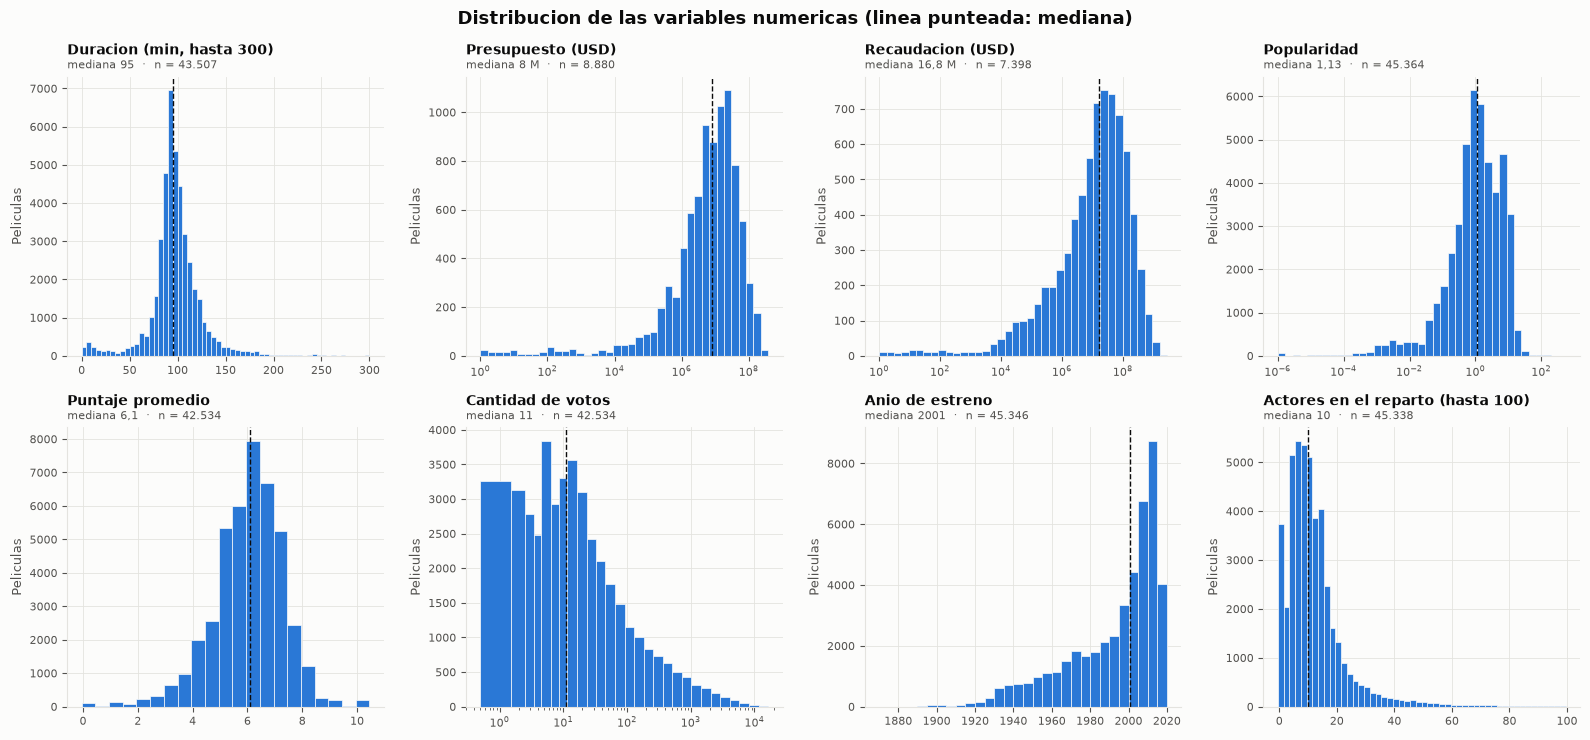

In [22]:
HISTOGRAMAS = [
    # (columna, titulo, escala logaritmica, bordes de los intervalos)
    # Las variables enteras o con un decimal usan intervalos alineados a sus
    # valores posibles; si no, algunos intervalos quedan vacios ("efecto peine").
    ("runtime", "Duracion (min, hasta 300)", False, np.arange(0, 305, 5)),
    ("budget", "Presupuesto (USD)", True, None),
    ("revenue", "Recaudacion (USD)", True, None),
    ("popularity", "Popularidad", True, None),
    ("vote_average", "Puntaje promedio", False, np.arange(-0.05, 10.5, 0.5)),
    ("vote_count", "Cantidad de votos", True, None),
    ("anio", "Anio de estreno", False, np.arange(1870, 2025, 5)),
    ("n_cast", "Actores en el reparto (hasta 100)", False, np.arange(-0.5, 101, 2)),
]

fig, ejes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax, (columna, titulo, logaritmica, bordes) in zip(ejes.flat, HISTOGRAMAS):
    datos = peliculas[columna].dropna()
    if bordes is not None:
        datos = datos[datos.between(bordes[0], bordes[-1])]
    if logaritmica:
        datos = datos[datos > 0]
        if columna == "vote_count":
            # votos: enteros chicos (la mitad tiene 11 o menos), asi que los intervalos
            # crecen x1,4 y cortan entre enteros para que cada uno contenga algun valor posible
            potencias = np.sqrt(2) ** np.arange(np.ceil(np.log(datos.max()) / np.log(np.sqrt(2))) + 1)
            bordes = np.concatenate([[0.5], np.unique(np.round(potencias)) + 0.5])
        else:
            bordes = np.logspace(np.log10(datos.min()), np.log10(datos.max()), 40)
        ax.set_xscale("log")
    ax.hist(datos, bins=bordes, color=COLOR_SERIE, edgecolor=SUPERFICIE, linewidth=0.5)
    mediana = datos.median()
    ax.axvline(mediana, color=TEXTO_PRIMARIO, linestyle="--", linewidth=1)
    ax.set_title(titulo, loc="left", fontsize=10, pad=16)
    texto_mediana = str(int(mediana)) if columna == "anio" else formato_compacto(mediana)
    ax.text(0, 1.02, f"mediana {texto_mediana}  ·  n = {formato_compacto(len(datos))}",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=8, color=TEXTO_SECUNDARIO)
    ax.set_ylabel("Peliculas")
fig.suptitle("Distribucion de las variables numericas (linea punteada: mediana)",
             fontsize=13, fontweight="bold", color=TEXTO_PRIMARIO)
plt.tight_layout()
plt.show()

### 8.5 Diagramas de caja y bigotes

La caja va del percentil 25 al 75 (la mitad central de las peliculas), la linea interna es la mediana y los bigotes llegan hasta 1,5 veces el rango intercuartil. Los puntos fuera de los bigotes son valores atipicos. Cada variable tiene su propio eje porque sus escalas no son comparables.

Para las variables sesgadas la caja se calcula sobre `log10(valor)`: si se calculara sobre los valores originales, el bigote inferior quedaria siempre pegado al minimo y la caja no diria nada.

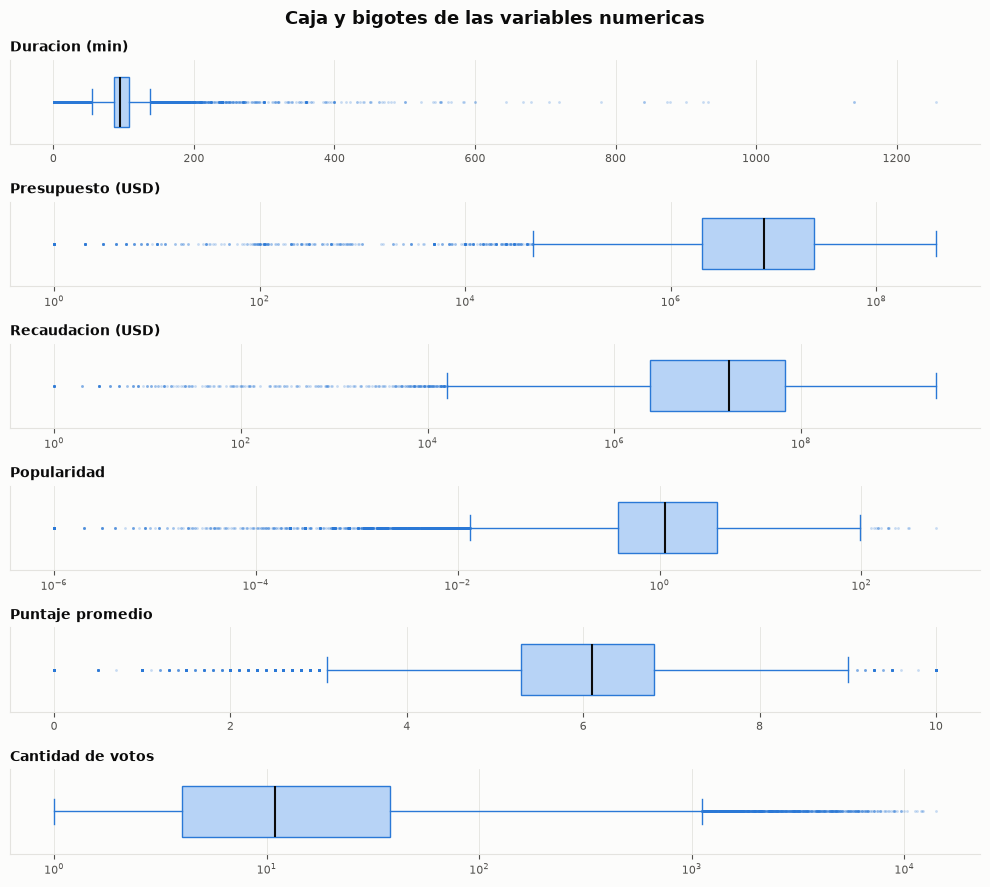

In [23]:
CAJAS = [
    ("runtime", "Duracion (min)", False),
    ("budget", "Presupuesto (USD)", True),
    ("revenue", "Recaudacion (USD)", True),
    ("popularity", "Popularidad", True),
    ("vote_average", "Puntaje promedio", False),
    ("vote_count", "Cantidad de votos", True),
]

fig, ejes = plt.subplots(len(CAJAS), 1, figsize=(10, 9))
for ax, (columna, titulo, logaritmica) in zip(ejes, CAJAS):
    datos = peliculas[columna].dropna()
    if logaritmica:
        datos = np.log10(datos[datos > 0])
        ax.xaxis.set_major_formatter(FORMATO_POTENCIA_10)
    ax.boxplot(
        datos, orientation="horizontal", widths=0.6, patch_artist=True,
        boxprops={"facecolor": "#b7d3f6", "edgecolor": COLOR_SERIE},
        medianprops={"color": TEXTO_PRIMARIO, "linewidth": 1.5},
        whiskerprops={"color": COLOR_SERIE},
        capprops={"color": COLOR_SERIE},
        flierprops={"marker": "o", "markersize": 2, "markerfacecolor": COLOR_SERIE,
                    "markeredgecolor": "none", "alpha": 0.25},
    )
    ax.set_yticks([])
    ax.set_title(titulo, loc="left", fontsize=10)
    ax.grid(axis="y", visible=False)
fig.suptitle("Caja y bigotes de las variables numericas", fontsize=13, fontweight="bold", color=TEXTO_PRIMARIO)
plt.tight_layout()
plt.show()

#### Puntaje promedio por genero

Una pelicula puede tener varios generos, asi que se "explota" la lista de generos (una fila por pelicula y genero). Solo se consideran peliculas con al menos 10 votos, porque con menos el promedio es muy poco confiable. Los generos se ordenan por mediana.

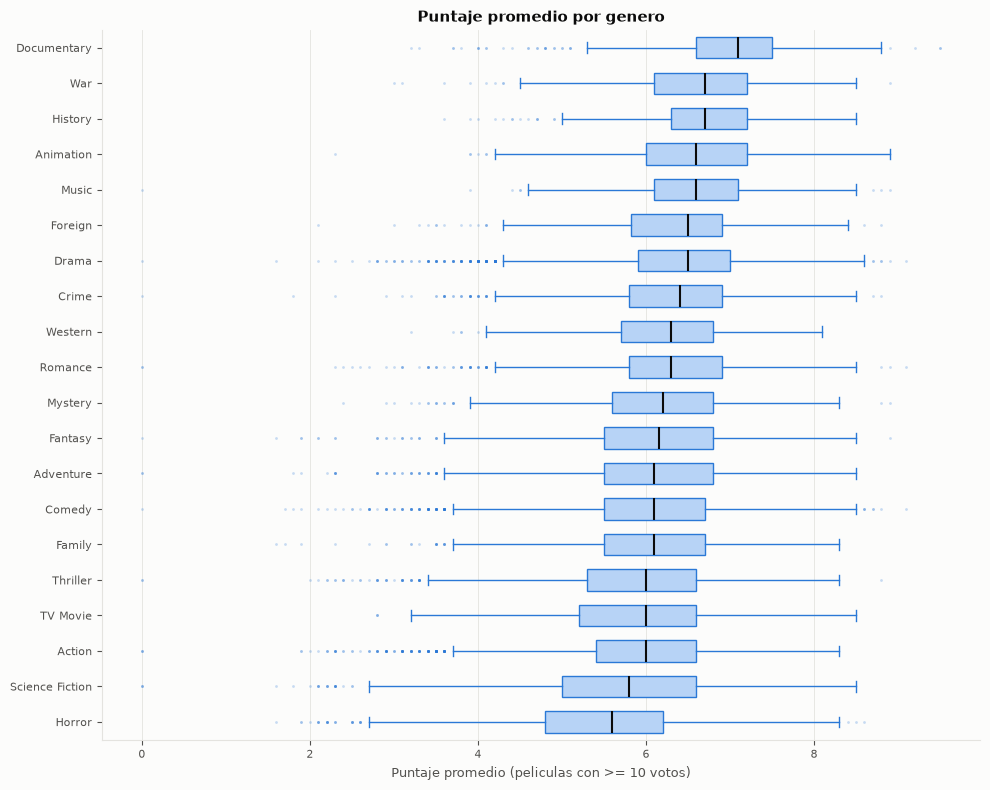

In [24]:
MINIMO_VOTOS = 10

puntaje_por_genero = (
    peliculas[peliculas["vote_count"] >= MINIMO_VOTOS][["genres", "vote_average"]]
    .explode("genres")
    .dropna()
)
orden_generos = (
    puntaje_por_genero.groupby("genres")["vote_average"].median().sort_values().index
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    [puntaje_por_genero.loc[puntaje_por_genero["genres"] == g, "vote_average"] for g in orden_generos],
    orientation="horizontal", tick_labels=orden_generos, widths=0.6, patch_artist=True,
    boxprops={"facecolor": "#b7d3f6", "edgecolor": COLOR_SERIE},
    medianprops={"color": TEXTO_PRIMARIO, "linewidth": 1.5},
    whiskerprops={"color": COLOR_SERIE},
    capprops={"color": COLOR_SERIE},
    flierprops={"marker": "o", "markersize": 2, "markerfacecolor": COLOR_SERIE,
                "markeredgecolor": "none", "alpha": 0.25},
)
ax.set_xlabel(f"Puntaje promedio (peliculas con >= {MINIMO_VOTOS} votos)")
ax.set_title("Puntaje promedio por genero")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 8.6 Distribuciones de las variables categoricas

Cuantas peliculas hay por genero, por idioma original, por anio de estreno y por estado. En generos, una pelicula cuenta una vez por cada genero que tiene.

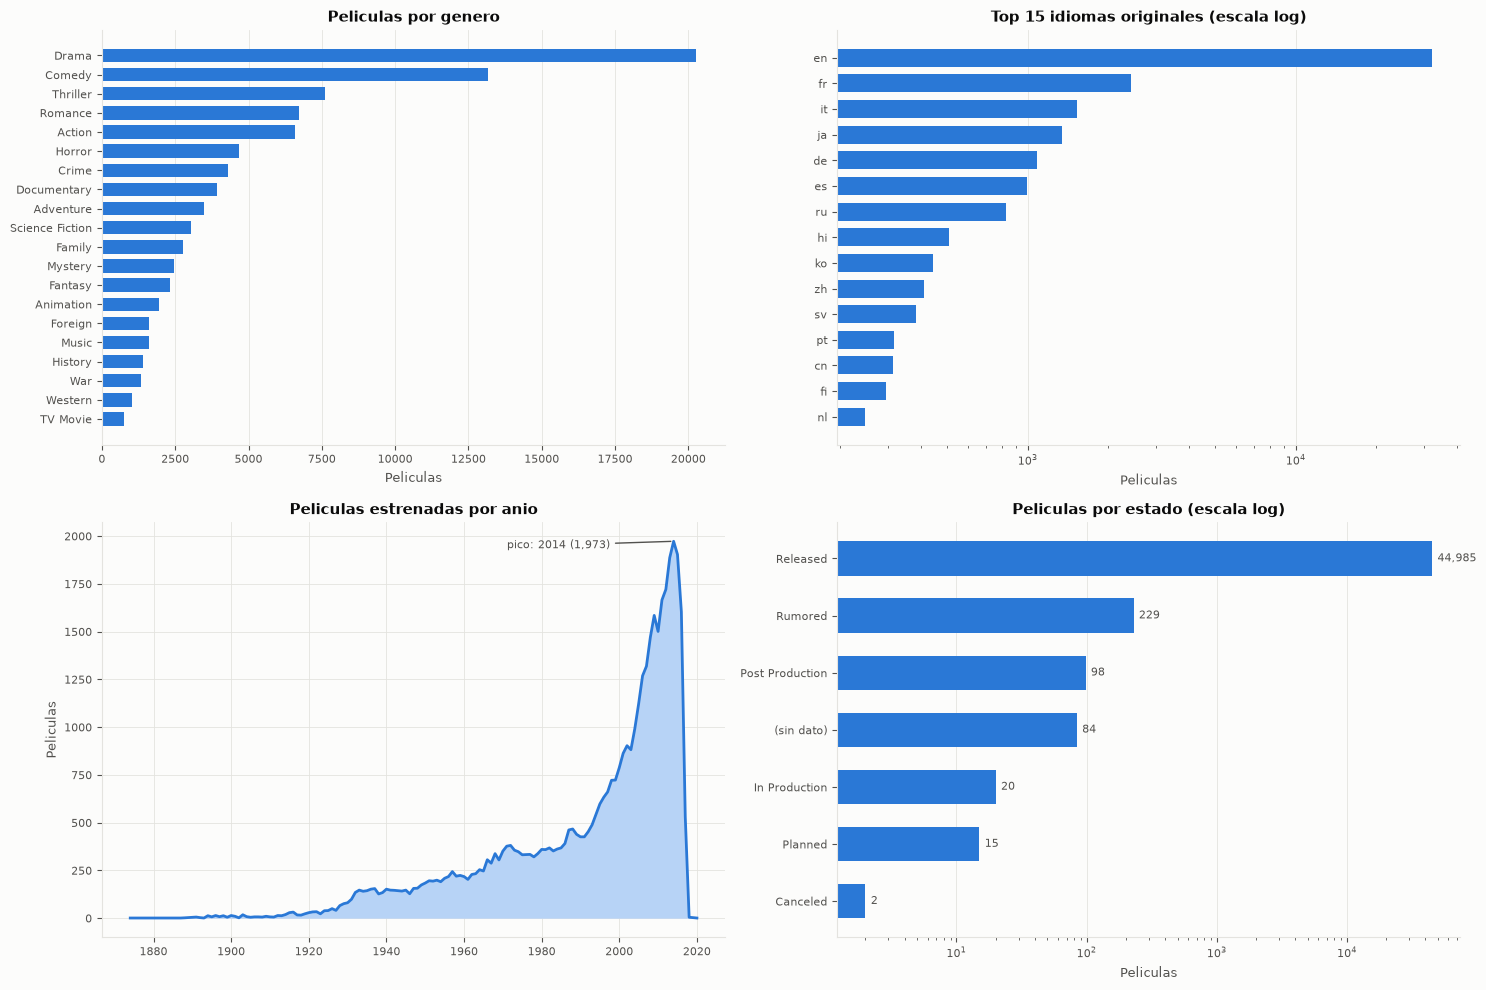

In [25]:
conteo_generos_eda = peliculas["genres"].explode().value_counts().sort_values()
conteo_idiomas = peliculas["original_language"].value_counts().head(15).sort_values()
conteo_anios = peliculas["anio"].value_counts().sort_index()
conteo_estados = peliculas["status"].fillna("(sin dato)").value_counts().sort_values()

fig, ejes = plt.subplots(2, 2, figsize=(15, 10))

ax = ejes[0, 0]
ax.barh(conteo_generos_eda.index, conteo_generos_eda.values, color=COLOR_SERIE, height=0.7)
ax.set_title("Peliculas por genero")
ax.set_xlabel("Peliculas")
ax.grid(axis="y", visible=False)

ax = ejes[0, 1]
ax.barh(conteo_idiomas.index, conteo_idiomas.values, color=COLOR_SERIE, height=0.7)
ax.set_xscale("log")
ax.set_title("Top 15 idiomas originales (escala log)")
ax.set_xlabel("Peliculas")
ax.grid(axis="y", visible=False)

ax = ejes[1, 0]
ax.fill_between(conteo_anios.index, conteo_anios.values, color="#b7d3f6", linewidth=0)
ax.plot(conteo_anios.index, conteo_anios.values, color=COLOR_SERIE, linewidth=2)
anio_pico = conteo_anios.idxmax()
ax.annotate(f"pico: {int(anio_pico)} ({conteo_anios.max():,})", (anio_pico, conteo_anios.max()),
            xytext=(-120, -5), textcoords="offset points", fontsize=8, color=TEXTO_SECUNDARIO,
            arrowprops={"arrowstyle": "-", "color": TEXTO_SECUNDARIO})
ax.set_title("Peliculas estrenadas por anio")
ax.set_ylabel("Peliculas")

ax = ejes[1, 1]
ax.barh(conteo_estados.index, conteo_estados.values, color=COLOR_SERIE, height=0.6)
ax.set_xscale("log")
for posicion, valor in enumerate(conteo_estados.values):
    ax.text(valor * 1.1, posicion, f"{valor:,}", va="center", fontsize=8, color=TEXTO_SECUNDARIO)
ax.set_title("Peliculas por estado (escala log)")
ax.set_xlabel("Peliculas")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### 8.7 Matriz de correlacion

Se usa la correlacion de **Spearman** (por rangos) en vez de la de Pearson porque las variables estan muy sesgadas y tienen valores extremos: Spearman mide si dos variables crecen juntas sin asumir una relacion lineal y no se deja arrastrar por los atipicos. Cada par se calcula con las peliculas que tienen ambos valores informados.

Azul = correlacion positiva, rojo = negativa, gris = sin relacion.

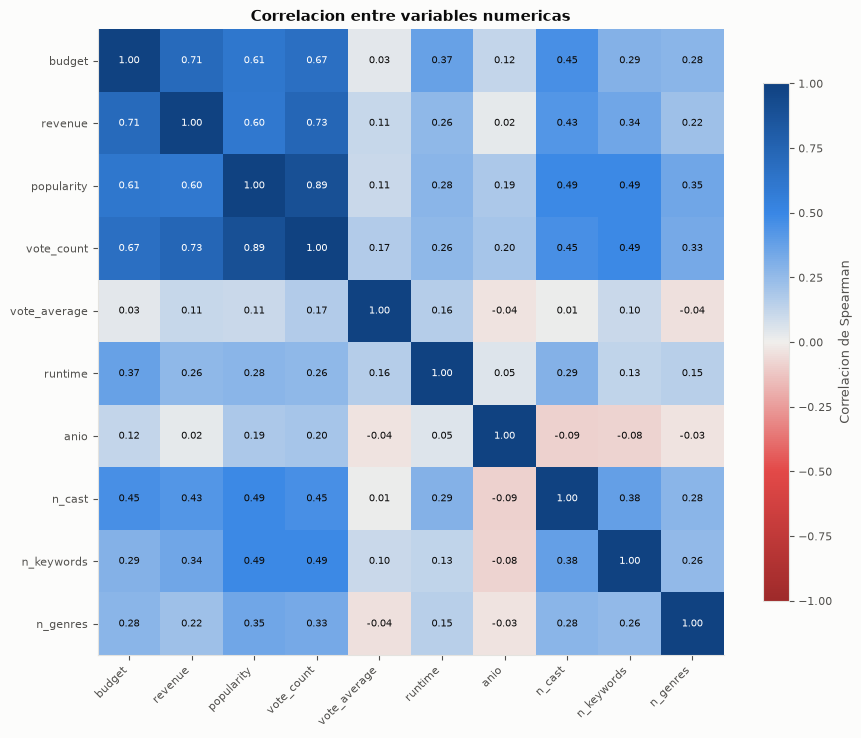

In [26]:
VARIABLES_CORRELACION = [
    "budget", "revenue", "popularity", "vote_count", "vote_average",
    "runtime", "anio", "n_cast", "n_keywords", "n_genres",
]
correlaciones = peliculas[VARIABLES_CORRELACION].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7.5))
imagen = ax.imshow(correlaciones, cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1)
ax.set_xticks(range(len(VARIABLES_CORRELACION)), VARIABLES_CORRELACION, rotation=45, ha="right")
ax.set_yticks(range(len(VARIABLES_CORRELACION)), VARIABLES_CORRELACION)
ax.grid(False)
for fila in range(len(VARIABLES_CORRELACION)):
    for columna in range(len(VARIABLES_CORRELACION)):
        valor = correlaciones.iloc[fila, columna]
        ax.text(columna, fila, f"{valor:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(valor) > 0.55 else TEXTO_PRIMARIO)
fig.colorbar(imagen, ax=ax, shrink=0.8, label="Correlacion de Spearman")
ax.set_title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()

### 8.8 Graficos tridimensionales de correlacion

**Presupuesto, recaudacion y cantidad de votos.** Solo peliculas con presupuesto y recaudacion informados. Los tres ejes estan en escala logaritmica (log10: 6 = un millon, 9 = mil millones). El plano es el ajuste lineal por minimos cuadrados de la recaudacion en funcion de las otras dos variables: muestra hacia donde "se inclina" la nube de puntos. El color de cada punto indica el puntaje promedio.

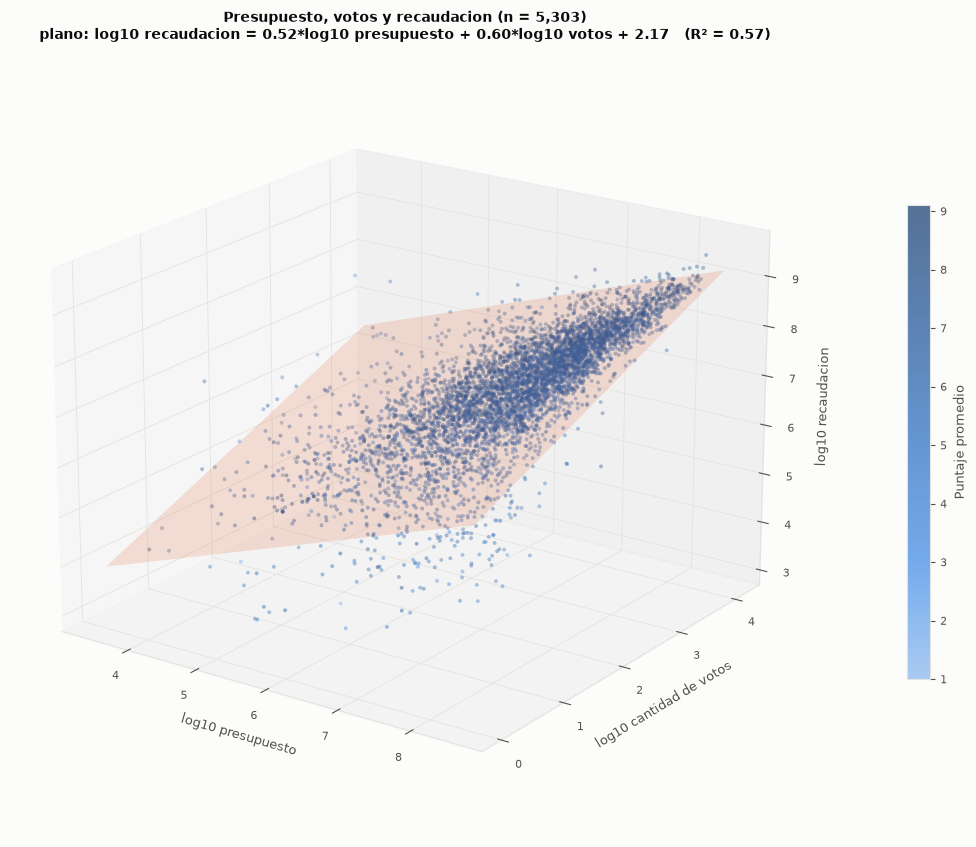

In [27]:
financieras = peliculas.dropna(subset=["budget", "revenue", "vote_count", "vote_average"])
financieras = financieras[(financieras["budget"] >= 1000) & (financieras["revenue"] >= 1000)]

x = np.log10(financieras["budget"])
y = np.log10(financieras["vote_count"])
z = np.log10(financieras["revenue"])

# plano z = a*x + b*y + c por minimos cuadrados
matriz = np.column_stack([x, y, np.ones(len(x))])
(a, b, c), *_ = np.linalg.lstsq(matriz, z, rcond=None)
r2 = 1 - ((z - matriz @ np.array([a, b, c])) ** 2).sum() / ((z - z.mean()) ** 2).sum()
malla_x, malla_y = np.meshgrid(np.linspace(x.min(), x.max(), 15), np.linspace(y.min(), y.max(), 15))

fig = plt.figure(figsize=(11, 8.5))
ax = fig.add_subplot(projection="3d")
puntos = ax.scatter(x, y, z, c=financieras["vote_average"], cmap=CMAP_SECUENCIAL,
                    s=8, alpha=0.7, linewidths=0)
ax.plot_surface(malla_x, malla_y, a * malla_x + b * malla_y + c, color=COLOR_SECUNDARIO,
                alpha=0.18, linewidth=0)
ax.set_xlabel("log10 presupuesto")
ax.set_ylabel("log10 cantidad de votos")
ax.set_zlabel("log10 recaudacion")
ax.view_init(elev=20, azim=-55)
fig.colorbar(puntos, ax=ax, shrink=0.6, pad=0.1, label="Puntaje promedio")
ax.set_title(f"Presupuesto, votos y recaudacion (n = {len(financieras):,})\n"
             f"plano: log10 recaudacion = {a:.2f}*log10 presupuesto + {b:.2f}*log10 votos + {c:.2f}"
             f"   (R² = {r2:.2f})", fontsize=10)
plt.tight_layout()
plt.show()

**Duracion, anio de estreno y puntaje.** Peliculas con al menos 50 votos (puntaje confiable) y duracion entre 40 y 240 minutos. El color es la popularidad (log10).

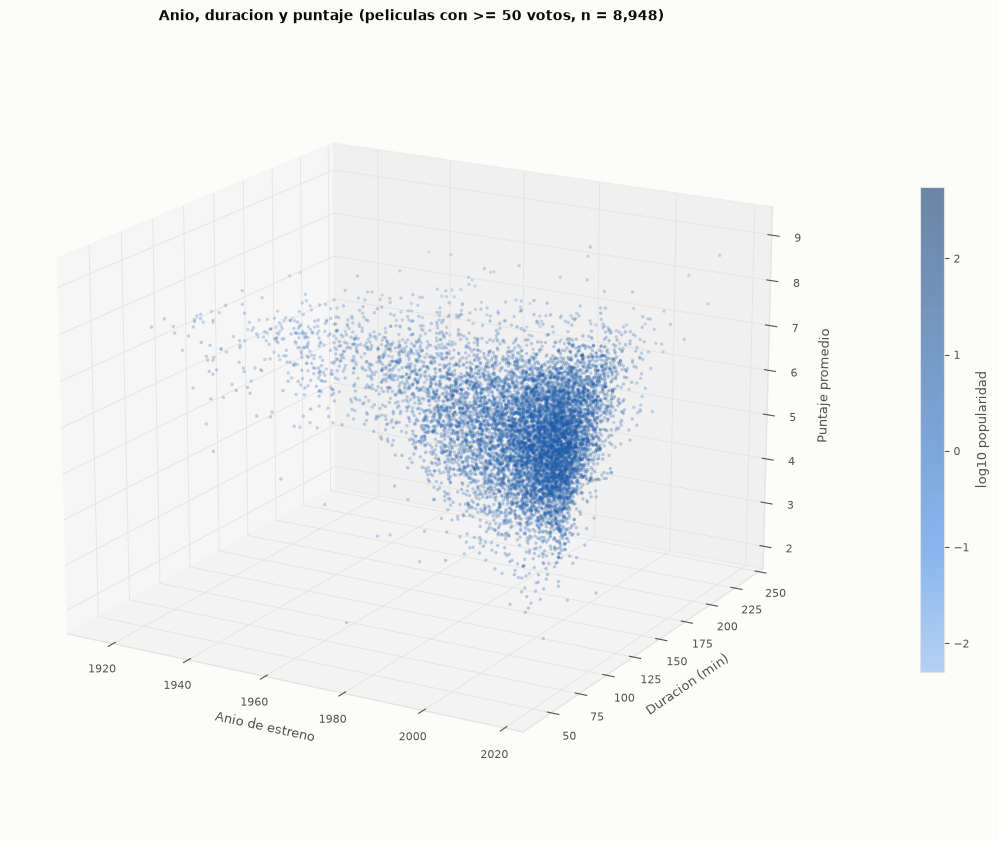

In [28]:
con_votos = peliculas.dropna(subset=["runtime", "anio", "vote_average", "popularity"])
con_votos = con_votos[
    (con_votos["vote_count"] >= 50) & con_votos["runtime"].between(40, 240) & (con_votos["popularity"] > 0)
]

fig = plt.figure(figsize=(11, 8.5))
ax = fig.add_subplot(projection="3d")
puntos = ax.scatter(con_votos["anio"], con_votos["runtime"], con_votos["vote_average"],
                    c=np.log10(con_votos["popularity"]), cmap=CMAP_SECUENCIAL,
                    s=6, alpha=0.6, linewidths=0)
ax.set_xlabel("Anio de estreno")
ax.set_ylabel("Duracion (min)")
ax.set_zlabel("Puntaje promedio")
ax.view_init(elev=18, azim=-60)
fig.colorbar(puntos, ax=ax, shrink=0.6, pad=0.1, label="log10 popularidad")
ax.set_title(f"Anio, duracion y puntaje (peliculas con >= 50 votos, n = {len(con_votos):,})", fontsize=10)
plt.tight_layout()
plt.show()

**La matriz de correlacion en 3D.** La misma matriz de la seccion 8.7, con la altura de cada barra igual a la correlacion: las barras hacia arriba (azules) son correlaciones positivas y hacia abajo (rojas) negativas. Se muestra solo la mitad inferior porque la matriz es simetrica, y se omite la diagonal (siempre vale 1).

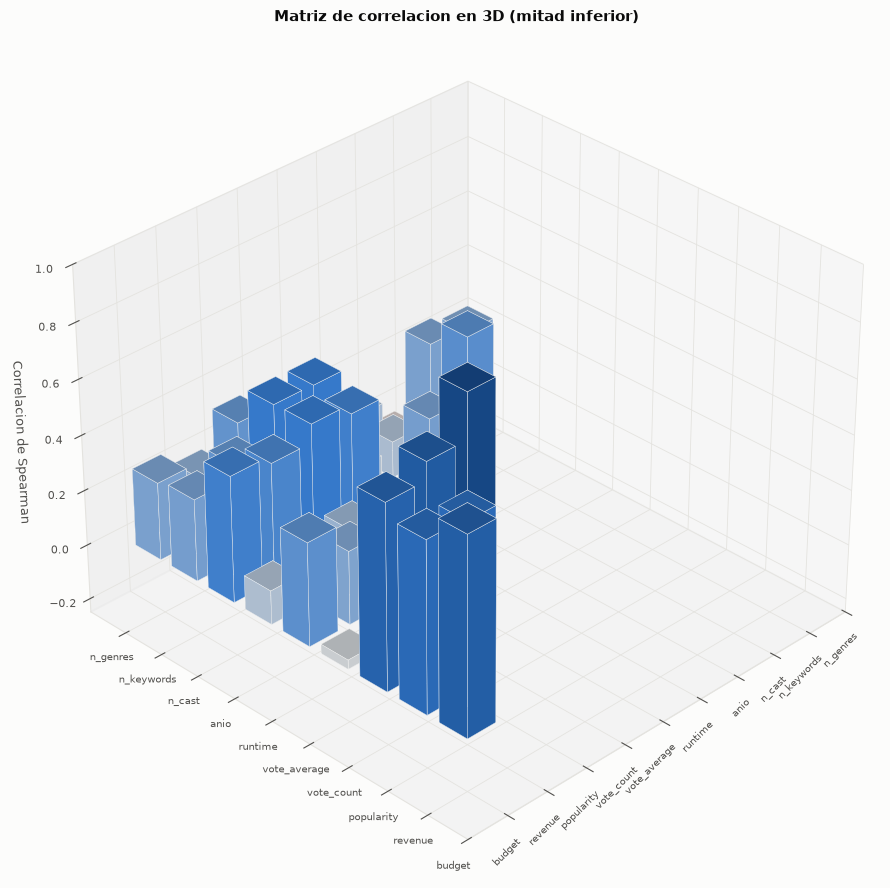

In [29]:
etiquetas = correlaciones.columns
cantidad = len(etiquetas)
filas, columnas = np.tril_indices(cantidad, k=-1)
alturas = correlaciones.values[filas, columnas]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection="3d")
ax.bar3d(columnas, filas, np.minimum(alturas, 0), 0.7, 0.7, np.abs(alturas),
         color=CMAP_DIVERGENTE((alturas + 1) / 2), edgecolor=SUPERFICIE, linewidth=0.3, shade=True)
ax.set_xticks(np.arange(cantidad) + 0.35, etiquetas, rotation=45, ha="right", fontsize=7)
ax.set_yticks(np.arange(cantidad) + 0.35, etiquetas, fontsize=7)
ax.set_zlabel("Correlacion de Spearman")
ax.set_zlim(min(-0.25, alturas.min()), 1)
ax.view_init(elev=32, azim=-135)
ax.set_title("Matriz de correlacion en 3D (mitad inferior)", fontsize=11)
plt.tight_layout()
plt.show()

### 8.9 Conclusiones

**Composicion del dataset**

- Son 45.433 peliculas, en su gran mayoria estrenadas (`Released`). La produccion crece sostenidamente desde los anios 90 y tiene su pico en 2014 (1.973 peliculas); la caida despues de 2016 no es real, sino que el dataset se armo a mediados de 2017.
- El 71% esta en ingles (`en`), seguido de lejos por frances, italiano y japones. Drama y comedia son por mucho los generos mas frecuentes.
- Los campos economicos son los mas incompletos: solo un 20% de las peliculas informa presupuesto y un 16% recaudacion. Ademas, entre los informados hay valores absurdos (presupuestos de 1 USD, probablemente cargados en millones), que aparecen como atipicos en la cola izquierda de los diagramas de caja.

**Distribuciones**

- La duracion se concentra alrededor de los 95 minutos, con una cola de series/compilados muy largos.
- El puntaje promedio es aproximadamente simetrico alrededor de 6,1.
- Presupuesto, recaudacion, popularidad y cantidad de votos estan fuertemente sesgados: la mayoria de las peliculas tiene valores chicos y unas pocas valores enormes (la mitad tiene 11 votos o menos, pero hay peliculas con mas de 14.000). Por eso conviene analizarlas en escala logaritmica y usar medianas en vez de promedios.
- Documental, guerra e historia son los generos con mejor puntaje mediano; terror es el peor por bastante margen.

**Correlaciones**

- Popularidad y cantidad de votos estan casi alineadas (0,89): las dos miden cuanta gente vio la pelicula. Presupuesto, recaudacion y votos tambien se mueven juntos (0,67 a 0,73).
- En el grafico 3D, el plano ajustado explica el 57% de la variacion de la recaudacion (en escala log) a partir del presupuesto y los votos.
- El **puntaje promedio casi no se relaciona con ninguna otra variable** (correlaciones de 0,17 o menos): gastar mas o ser mas popular no hace que una pelicula este mejor puntuada. Tampoco la duracion ni el anio de estreno lo explican, como se ve en la nube sin forma del segundo grafico 3D.